# Modelo SVM

#### Propensión de compra de un iphone (target=compra/ no compra)

- X1: Ingresos mensuales del cliente(euros). Obviamente, a mayor nivel de ingresos, más facilidad para comprar un telefono de gama alta.
- X2: Puntuación de fidelidad a la marca/tecnologia(score de 1 a 100, donde 100 es un fan absoluto de apple o la tecnologia y 1 es alguien a quien no le importa los telefonos)

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes clave de Scikit-Learn para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [96]:
datos_clientes = [
    {"Ingresos_Mensuales": 2373.49, "Score_Fidelidad": 95.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 4353.47, "Score_Fidelidad": 59.27, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3591.95, "Score_Fidelidad": 16.44, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3135.70, "Score_Fidelidad": 16.44, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1630.98, "Score_Fidelidad": 86.75, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1630.73, "Score_Fidelidad": 60.51, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1297.48, "Score_Fidelidad": 71.10, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4075.61, "Score_Fidelidad": 2.18, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4058.41, "Score_Fidelidad": 97.00, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3543.43, "Score_Fidelidad": 83.41, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1170.92, "Score_Fidelidad": 22.02, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4396.49, "Score_Fidelidad": 19.00, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3964.33, "Score_Fidelidad": 19.16, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1822.42, "Score_Fidelidad": 53.22, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1718.91, "Score_Fidelidad": 44.20, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1723.18, "Score_Fidelidad": 29.83, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2134.80, "Score_Fidelidad": 62.13, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2136.19, "Score_Fidelidad": 46.22, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2568.21, "Score_Fidelidad": 79.03, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2089.47, "Score_Fidelidad": 20.73, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3122.12, "Score_Fidelidad": 51.52, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1572.76, "Score_Fidelidad": 59.88, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2097.43, "Score_Fidelidad": 5.48, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2346.52, "Score_Fidelidad": 61.21, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2651.93, "Score_Fidelidad": 17.89, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3792.83, "Score_Fidelidad": 6.94, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2862.33, "Score_Fidelidad": 52.81, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2841.05, "Score_Fidelidad": 44.13, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3114.73, "Score_Fidelidad": 30.34, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1258.11, "Score_Fidelidad": 71.30, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3165.44, "Score_Fidelidad": 40.71, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1679.51, "Score_Fidelidad": 11.23, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1321.41, "Score_Fidelidad": 91.13, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4323.01, "Score_Fidelidad": 18.06, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4183.05, "Score_Fidelidad": 9.92, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2228.62, "Score_Fidelidad": 43.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2133.51, "Score_Fidelidad": 50.31, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1429.62, "Score_Fidelidad": 66.08, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2064.21, "Score_Fidelidad": 99.43, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2623.51, "Score_Fidelidad": 5.42, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1515.22, "Score_Fidelidad": 38.30, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2596.18, "Score_Fidelidad": 95.82, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1215.11, "Score_Fidelidad": 91.07, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4124.96, "Score_Fidelidad": 49.38, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2043.90, "Score_Fidelidad": 57.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3317.02, "Score_Fidelidad": 64.91, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2187.35, "Score_Fidelidad": 73.08, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3141.48, "Score_Fidelidad": 9.07, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3020.25, "Score_Fidelidad": 3.73, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1729.13, "Score_Fidelidad": 62.90, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4252.02, "Score_Fidelidad": 44.97, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2068.79, "Score_Fidelidad": 89.81, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2577.63, "Score_Fidelidad": 38.16, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1856.78, "Score_Fidelidad": 9.94, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2420.73, "Score_Fidelidad": 71.97, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1581.44, "Score_Fidelidad": 46.52, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4180.70, "Score_Fidelidad": 17.53, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2901.60, "Score_Fidelidad": 59.84, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 4339.63, "Score_Fidelidad": 65.57, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3448.96, "Score_Fidelidad": 7.50, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2736.63, "Score_Fidelidad": 61.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3939.99, "Score_Fidelidad": 83.58, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3016.36, "Score_Fidelidad": 12.39, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3918.06, "Score_Fidelidad": 43.10, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3139.75, "Score_Fidelidad": 78.47, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1139.54, "Score_Fidelidad": 56.59, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3612.30, "Score_Fidelidad": 43.60, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1757.21, "Score_Fidelidad": 66.82, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1419.06, "Score_Fidelidad": 35.88, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4181.99, "Score_Fidelidad": 60.10, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1475.29, "Score_Fidelidad": 37.15, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2866.52, "Score_Fidelidad": 78.71, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3280.90, "Score_Fidelidad": 80.20, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3051.48, "Score_Fidelidad": 81.39, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 4048.96, "Score_Fidelidad": 30.65, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 4059.63, "Score_Fidelidad": 23.36, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1807.56, "Score_Fidelidad": 9.47, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2686.04, "Score_Fidelidad": 43.65, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3144.33, "Score_Fidelidad": 19.33, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1475.52, "Score_Fidelidad": 51.52, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1928.31, "Score_Fidelidad": 29.23, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3497.66, "Score_Fidelidad": 67.21, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3816.63, "Score_Fidelidad": 72.58, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2555.22, "Score_Fidelidad": 77.20, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1978.85, "Score_Fidelidad": 63.85, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4209.68, "Score_Fidelidad": 23.94, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4353.49, "Score_Fidelidad": 25.10, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2901.81, "Score_Fidelidad": 96.53, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3878.69, "Score_Fidelidad": 22.04, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3469.74, "Score_Fidelidad": 58.74, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1803.95, "Score_Fidelidad": 67.63, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1827.20, "Score_Fidelidad": 61.64, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1133.58, "Score_Fidelidad": 46.51, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3448.91, "Score_Fidelidad": 51.05, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2185.04, "Score_Fidelidad": 92.51, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2596.53, "Score_Fidelidad": 15.65, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1395.73, "Score_Fidelidad": 58.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2528.32, "Score_Fidelidad": 96.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 4181.71, "Score_Fidelidad": 70.08, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3931.35, "Score_Fidelidad": 66.86, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2315.68, "Score_Fidelidad": 70.36, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1108.91, "Score_Fidelidad": 99.41, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1851.63, "Score_Fidelidad": 6.84, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4278.11, "Score_Fidelidad": 74.41, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3081.91, "Score_Fidelidad": 46.85, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4031.51, "Score_Fidelidad": 47.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1695.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4351.91, "Score_Fidelidad": 94.13, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2420.52, "Score_Fidelidad": 73.19, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3521.80, "Score_Fidelidad": 19.41, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3135.91, "Score_Fidelidad": 80.20, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1215.80, "Score_Fidelidad": 35.53, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2695.12, "Score_Fidelidad": 78.43, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3612.95, "Score_Fidelidad": 95.19, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3021.11, "Score_Fidelidad": 68.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2953.51, "Score_Fidelidad": 54.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3521.43, "Score_Fidelidad": 45.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1895.11, "Score_Fidelidad": 88.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4122.95, "Score_Fidelidad": 12.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2135.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4012.35, "Score_Fidelidad": 82.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3315.63, "Score_Fidelidad": 9.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2045.13, "Score_Fidelidad": 78.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2945.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1135.53, "Score_Fidelidad": 12.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4351.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1285.31, "Score_Fidelidad": 85.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3945.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1845.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2531.62, "Score_Fidelidad": 68.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3122.35, "Score_Fidelidad": 81.19, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2135.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4412.95, "Score_Fidelidad": 3.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3012.35, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1152.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3812.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2635.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1545.13, "Score_Fidelidad": 88.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3445.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1635.53, "Score_Fidelidad": 42.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4251.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1985.31, "Score_Fidelidad": 85.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3645.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2145.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2331.62, "Score_Fidelidad": 68.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2922.35, "Score_Fidelidad": 81.19, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2535.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4112.95, "Score_Fidelidad": 13.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3212.35, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1452.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3512.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2935.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1245.13, "Score_Fidelidad": 88.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3145.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1935.53, "Score_Fidelidad": 32.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4051.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2285.31, "Score_Fidelidad": 85.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3345.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2445.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2031.62, "Score_Fidelidad": 68.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2622.35, "Score_Fidelidad": 81.19, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2835.53, "Score_Fidelidad": 53.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3912.95, "Score_Fidelidad": 23.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3412.35, "Score_Fidelidad": 62.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1752.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3212.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3235.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1145.13, "Score_Fidelidad": 78.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2845.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2235.53, "Score_Fidelidad": 52.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3851.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2585.31, "Score_Fidelidad": 85.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3045.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2745.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1731.62, "Score_Fidelidad": 68.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2322.35, "Score_Fidelidad": 81.19, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3135.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3612.95, "Score_Fidelidad": 13.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3612.35, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2052.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2912.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3535.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1445.13, "Score_Fidelidad": 88.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2545.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2535.53, "Score_Fidelidad": 42.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3651.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2885.31, "Score_Fidelidad": 75.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2745.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3045.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1431.62, "Score_Fidelidad": 68.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2022.35, "Score_Fidelidad": 81.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3435.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3312.95, "Score_Fidelidad": 13.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4012.35, "Score_Fidelidad": 62.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2352.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2612.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3835.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1745.13, "Score_Fidelidad": 58.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2245.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2835.53, "Score_Fidelidad": 12.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3451.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3185.31, "Score_Fidelidad": 85.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2445.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3345.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1131.62, "Score_Fidelidad": 68.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1722.35, "Score_Fidelidad": 81.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3735.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3012.95, "Score_Fidelidad": 43.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4312.35, "Score_Fidelidad": 32.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2652.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2312.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4135.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2045.13, "Score_Fidelidad": 38.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1945.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3135.53, "Score_Fidelidad": 32.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3251.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3485.31, "Score_Fidelidad": 45.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2145.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3645.53, "Score_Fidelidad": 45.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1331.62, "Score_Fidelidad": 38.12, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1422.35, "Score_Fidelidad": 51.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4035.53, "Score_Fidelidad": 23.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2712.95, "Score_Fidelidad": 13.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3712.35, "Score_Fidelidad": 52.11, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2952.63, "Score_Fidelidad": 39.43, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 2012.35, "Score_Fidelidad": 72.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 4335.63, "Score_Fidelidad": 19.43, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 2345.13, "Score_Fidelidad": 18.11, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 1645.31, "Score_Fidelidad": 68.32, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3435.53, "Score_Fidelidad": 32.19, "Compra_iPhone": 0},
    {"Ingresos_Mensuales": 3051.62, "Score_Fidelidad": 54.12, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 3785.31, "Score_Fidelidad": 25.32, "Compra_iPhone": 1},
    {"Ingresos_Mensuales": 1845.11, "Score_Fidelidad": 92.11, "Compra_iPhone": 0},
]

In [97]:
df_iphone = pd.DataFrame(datos_clientes)
display(df_iphone)

,Ingresos_Mensuales,Score_Fidelidad,Compra_iPhone
0,2373.49,95.12,1
1,4353.47,59.27,1
2,3591.95,16.44,0
3,3135.70,16.44,0
4,1630.98,86.75,0
...,...,...,...
228,1645.31,68.32,0
229,3435.53,32.19,0
230,3051.62,54.12,1
231,3785.31,25.32,1


In [98]:
# Definición de los conjuntos de datos

X = df_iphone[["Ingresos_Mensuales","Score_Fidelidad"]]
y = df_iphone["Compra_iPhone"]

In [99]:
# Separar Train-Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.25, 
    stratify=y, 
    random_state=42
)

- Estratificado porque es un ejercicio de clasificación.

- Hay algoritmos que es necesario normalizar. Tenemos que normalizar para que cuando tengamos variables en diferentes rangos porque el algoritmo tiende a coger los valores más altos y no hace caso a los valores más bajos. 

### IMPORTANTE
- Siempre después del train/test split — nunca antes. Y la razón tiene que ver con evitar lo que se llama data leakage (fuga de datos).
- 1º - Primero se divide
data_train, data_test = train_test_split(data_, test_size=0.2, random_state=42)

- 2º - El scaler "aprende" (fit) SOLO con train
scaler = StandardScaler()
data_train_scaled[variables_predictoras] = scaler.fit_transform(data_train[variables_predictoras])

- 3º - Al test solo se le APLICA (transform) la transformación ya aprendida en train
data_test_scaled[variables_predictoras] = scaler.transform(data_test[variables_predictoras])

In [100]:
# Estandarizar los valores
escalador = StandardScaler()

# Ajustar el escalador con el conjunto de entrenamiento
X_train_scaled = escalador.fit_transform(X_train)
X_test_scaled = escalador.fit_transform(X_test)

In [101]:
# Construcción del modelo

modelo_svm_iphone = SVC(kernel="linear", C=1.0, random_state=42)

# Un C muy grande puede producir un sobreajuste. 

modelo_svm_iphone.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [102]:
# Generar predicciones

y_pred = modelo_svm_iphone.predict(X_test_scaled)

In [103]:
print(classification_report(y_test, y_pred, target_names=["No compra(0)", "Compra (1)"]))


              precision    recall  f1-score   support

No compra(0)       0.95      0.97      0.96        37
  Compra (1)       0.95      0.91      0.93        22

    accuracy                           0.95        59
   macro avg       0.95      0.94      0.95        59
weighted avg       0.95      0.95      0.95        59



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


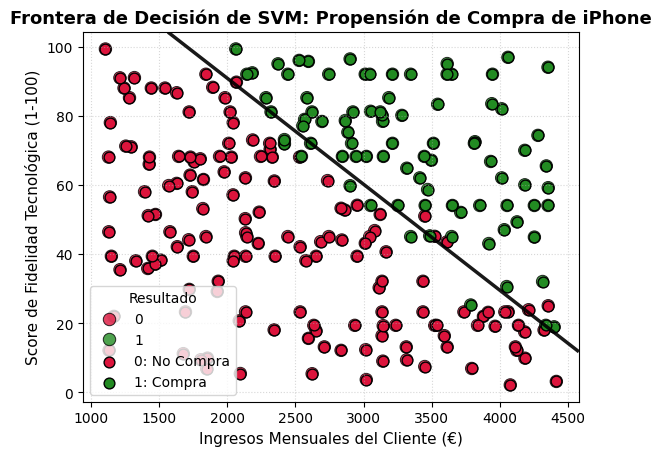

In [105]:
# Visualización del modelo

sns.scatterplot(
    data=df_iphone,
    x="Ingresos_Mensuales",
    y="Score_Fidelidad",
    hue="Compra_iPhone",
    palette={0: "crimson", 1: "forestgreen"},
    s=80,
    edgecolor="black",
    alpha=0.8
)

plt.scatter(
    df_iphone[df_iphone["Compra_iPhone"] == 0]["Ingresos_Mensuales"],
    df_iphone[df_iphone["Compra_iPhone"] == 0]["Score_Fidelidad"],
    color="crimson",
    label="0: No Compra",
    s=60,
    edgecolors="black"
)

plt.scatter(
    df_iphone[df_iphone["Compra_iPhone"] == 1]["Ingresos_Mensuales"],
    df_iphone[df_iphone["Compra_iPhone"] == 1]["Score_Fidelidad"],
    color="forestgreen",
    label="1: Compra",
    s=60,
    edgecolors="black"
)

# El SVM encuentra una línea matemática divisoria.
# Vamos a dibujarla en base al modelo entrenado.

w = modelo_svm_iphone.coef_[0]
b = modelo_svm_iphone.intercept_[0]

# Generamos puntos en el eje X para trazar la línea
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Escalamos los datos para evaluar el modelo
xy_scaled = escalador.transform(xy)

Z = modelo_svm_iphone.decision_function(xy_scaled).reshape(XX.shape)

# Dibujamos la frontera de decisión
ax.contour(
    XX,
    YY,
    Z,
    colors="black",
    levels=[0],
    alpha=0.9,
    linestyles=["-"],
    linewidths=[2.5]
)

plt.title(
    "Frontera de Decisión de SVM: Propensión de Compra de iPhone",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Ingresos Mensuales del Cliente (€)",
    fontsize=11
)

plt.ylabel(
    "Score de Fidelidad Tecnológica (1-100)",
    fontsize=11
)

plt.legend(title="Resultado")
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

In [114]:
# Construcción del modelo

modelo_svm_iphone = SVC(kernel="poly", degree=2, C=1.0, gamma= "scale", coef0=1, random_state=42)

# Un C muy grande puede producir un sobreajuste. 

modelo_svm_iphone.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,1
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


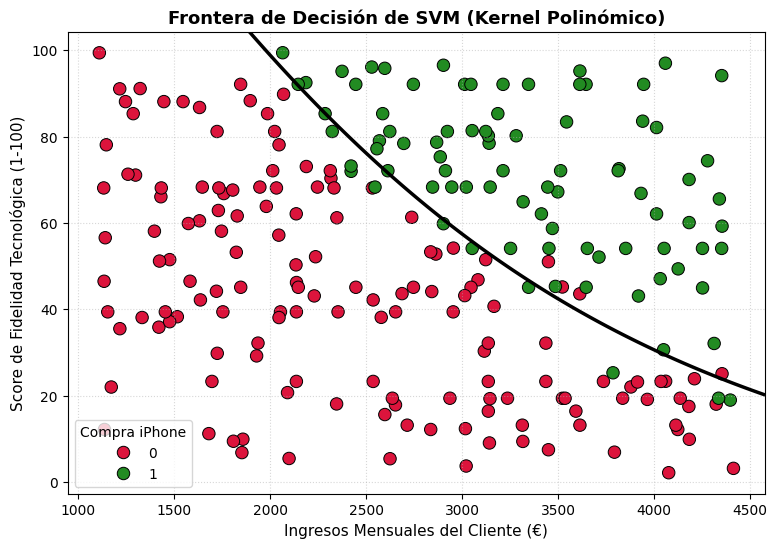

In [110]:
# Visualización del modelo

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_iphone,
    x="Ingresos_Mensuales",
    y="Score_Fidelidad",
    hue="Compra_iPhone",
    palette={0: "crimson", 1: "forestgreen"},
    s=80,
    edgecolor="black"
)

# Obtenemos los límites del gráfico
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Creamos una malla de puntos
xx = np.linspace(xlim[0], xlim[1], 300)
yy = np.linspace(ylim[0], ylim[1], 300)

XX, YY = np.meshgrid(xx, yy)

# Convertimos la malla en una matriz de observaciones
xy = np.c_[XX.ravel(), YY.ravel()]

# Escalamos la malla igual que los datos de entrenamiento
xy_scaled = escalador.transform(xy)

# Calculamos la función de decisión
Z = modelo_svm_iphone.decision_function(xy_scaled)
Z = Z.reshape(XX.shape)

# Dibujamos la frontera de decisión
ax.contour(
    XX,
    YY,
    Z,
    levels=[0],
    colors="black",
    linewidths=2.5
)

plt.title(
    "Frontera de Decisión de SVM (Kernel Polinómico)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Ingresos Mensuales del Cliente (€)",
    fontsize=11
)

plt.ylabel(
    "Score de Fidelidad Tecnológica (1-100)",
    fontsize=11
)

plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(title="Compra iPhone")

plt.show()

In [111]:
modelo_svm_iphone = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

modelo_svm_iphone.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


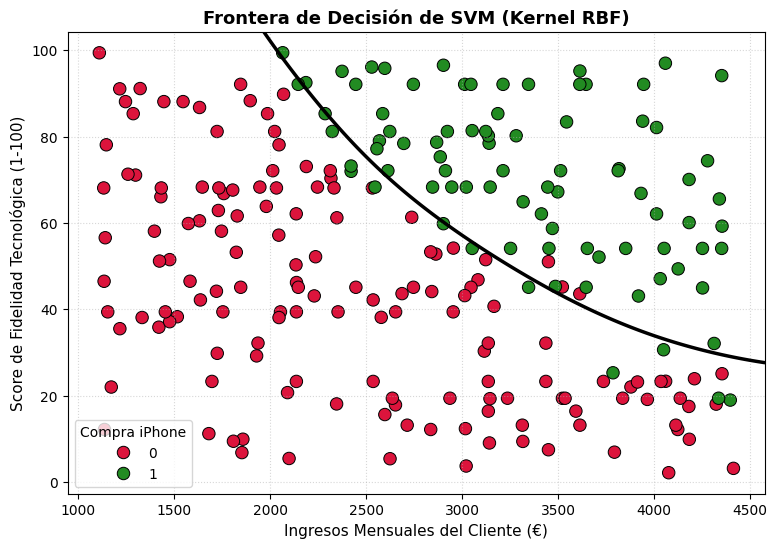

In [112]:
# Visualización del modelo

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_iphone,
    x="Ingresos_Mensuales",
    y="Score_Fidelidad",
    hue="Compra_iPhone",
    palette={0: "crimson", 1: "forestgreen"},
    s=80,
    edgecolor="black"
)

# Límites del gráfico
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Creamos una malla de puntos
xx = np.linspace(xlim[0], xlim[1], 300)
yy = np.linspace(ylim[0], ylim[1], 300)

XX, YY = np.meshgrid(xx, yy)

# Convertimos la malla en observaciones
xy = np.c_[XX.ravel(), YY.ravel()]

# Escalamos la malla
xy_scaled = escalador.transform(xy)

# Calculamos la función de decisión del SVM RBF
Z = modelo_svm_iphone.decision_function(xy_scaled)
Z = Z.reshape(XX.shape)

# Dibujamos la frontera de decisión
ax.contour(
    XX,
    YY,
    Z,
    levels=[0],
    colors="black",
    linewidths=2.5
)

plt.title(
    "Frontera de Decisión de SVM (Kernel RBF)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Ingresos Mensuales del Cliente (€)",
    fontsize=11
)

plt.ylabel(
    "Score de Fidelidad Tecnológica (1-100)",
    fontsize=11
)

plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(title="Compra iPhone")

plt.show()

# Este es un visual más profesional. Solo tenemos que arrancar el modelo que queremos ver y luego funciona para todos los modelos para visualizarlo. 

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


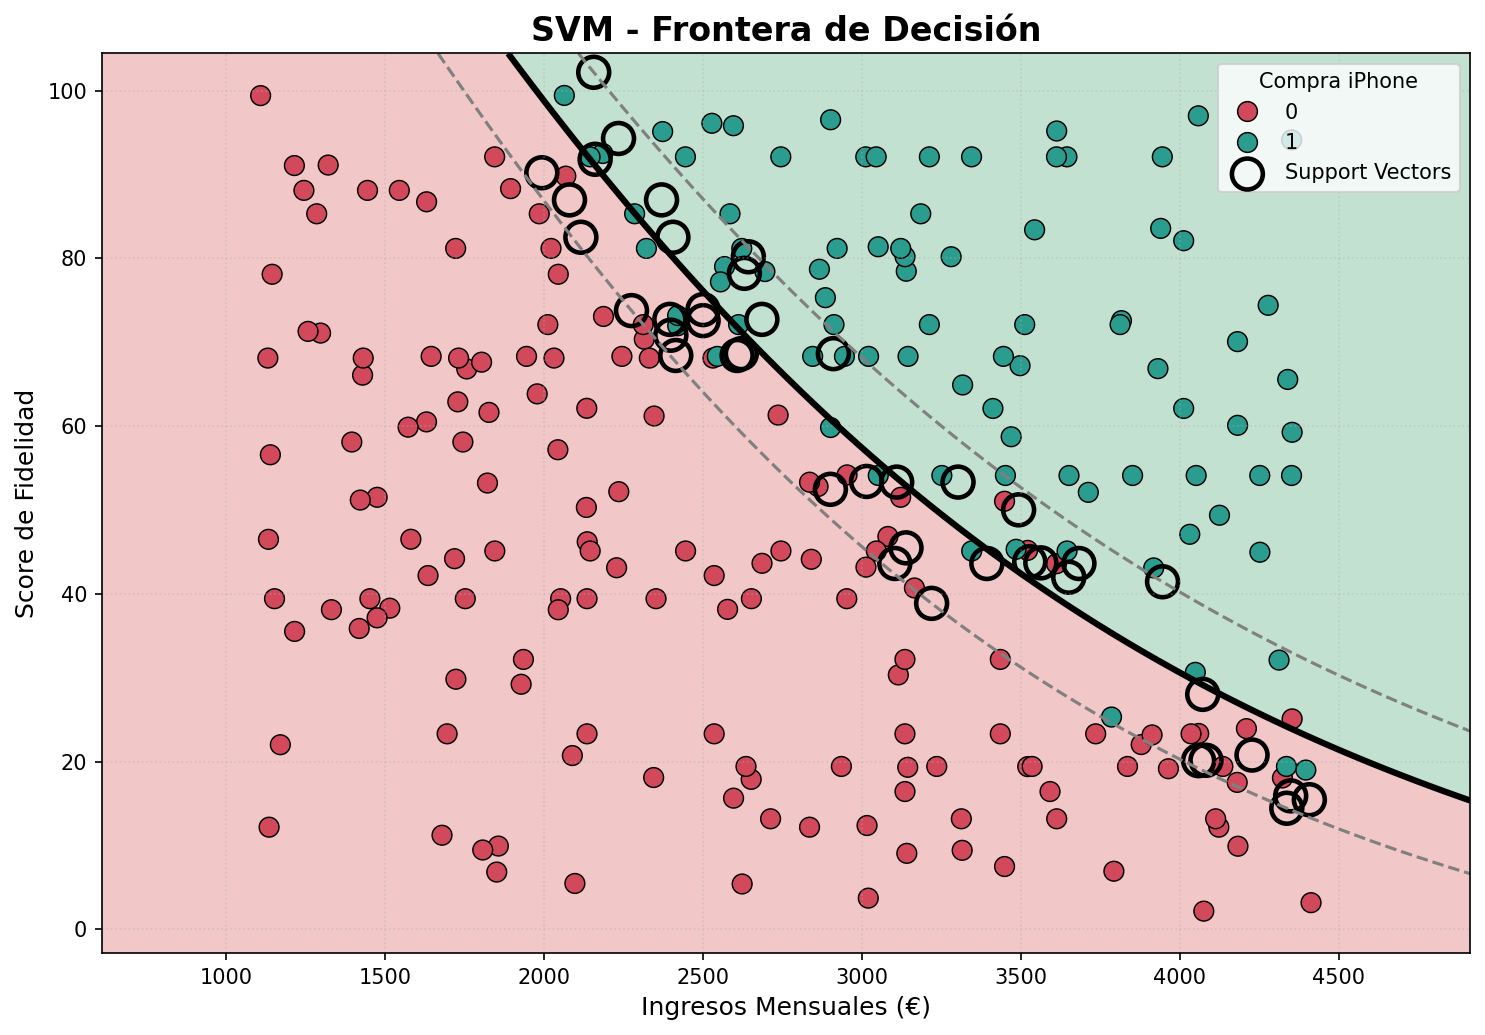

In [115]:
plt.figure(figsize=(10, 7), dpi=150)

# ==========================
# Malla para la predicción
# ==========================

x_min = df_iphone["Ingresos_Mensuales"].min() - 500
x_max = df_iphone["Ingresos_Mensuales"].max() + 500

y_min = df_iphone["Score_Fidelidad"].min() - 5
y_max = df_iphone["Score_Fidelidad"].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = escalador.transform(grid)

Z = modelo_svm_iphone.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# ==========================
# Regiones de decisión
# ==========================

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap="RdYlGn"
)

# ==========================
# Frontera de decisión
# ==========================

decision = modelo_svm_iphone.decision_function(grid_scaled)
decision = decision.reshape(xx.shape)

plt.contour(
    xx,
    yy,
    decision,
    levels=[-1, 0, 1],
    colors=["gray", "black", "gray"],
    linestyles=["--", "-", "--"],
    linewidths=[1.5, 3, 1.5]
)

# ==========================
# Datos reales
# ==========================

sns.scatterplot(
    data=df_iphone,
    x="Ingresos_Mensuales",
    y="Score_Fidelidad",
    hue="Compra_iPhone",
    palette={
        0: "#D1495B",
        1: "#2A9D8F"
    },
    s=90,
    edgecolor="black",
    linewidth=0.7
)

# ==========================
# Vectores soporte
# ==========================

support_vectors = escalador.inverse_transform(
    modelo_svm_iphone.support_vectors_
)

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=2.2,
    label="Support Vectors"
)

# ==========================
# Títulos
# ==========================

plt.title(
    "SVM - Frontera de Decisión",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Ingresos Mensuales (€)",
    fontsize=12
)

plt.ylabel(
    "Score de Fidelidad",
    fontsize=12
)

plt.grid(True, linestyle=":", alpha=0.4)

plt.legend(
    title="Compra iPhone",
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()